# Reinforcement Learning Assignment: Text Flappy Bird

**Course:** 3MD3220 - Reinforcement Learning  
**Author:** [Your Name Here]  
**Date:** April 2026

---

## Objective

This notebook implements and compares two reinforcement learning agents on the Text Flappy Bird environment:
1. **Monte Carlo Control** with epsilon-greedy policy (first-visit, constant-alpha)
2. **SARSA(λ)** with eligibility traces (Section 12.7 of Sutton & Barto)

Both agents are implemented using the **RL-Glue framework** for standardized agent-environment interaction.

## 1. Setup and Installation

In [63]:
# Install the Text Flappy Bird Gym environment
!pip install git+https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git -q

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import gymnasium as gym
import text_flappy_bird_gym
from abc import ABCMeta, abstractmethod
import pickle

np.random.seed(42)

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'figure.figsize': [12, 5]})

## 2. RL-Glue Framework

We use the RL-Glue framework to standardize agent-environment interaction. This provides:
- **BaseAgent**: Abstract class defining the agent interface
- **BaseEnvironment**: Abstract class defining the environment interface  
- **RLGlue**: Orchestrator that manages the agent-environment interaction loop

In [65]:
# BaseAgent - Abstract class for all agents
class BaseAgent:
    """Abstract base class for RL agents.
    
    All agents must implement: agent_init, agent_start, agent_step, 
    agent_end, agent_cleanup, agent_message
    """
    __metaclass__ = ABCMeta

    def __init__(self):
        pass

    @abstractmethod
    def agent_init(self, agent_info={}):
        """Setup for the agent called when the experiment first starts."""

    @abstractmethod
    def agent_start(self, observation):
        """First action selection at episode start. Returns action."""

    @abstractmethod
    def agent_step(self, reward, observation):
        """Step taken by agent. Returns action."""

    @abstractmethod
    def agent_end(self, reward):
        """Called when agent reaches terminal state."""

    def agent_cleanup(self):
        """Cleanup after experiment ends."""
        pass

    def agent_message(self, message):
        """Communication channel for getting agent info."""
        return "Message not understood."

In [66]:
# BaseEnvironment - Abstract class for all environments
class BaseEnvironment:
    """Abstract base class for RL environments.
    
    All environments must implement: env_init, env_start, env_step,
    env_cleanup, env_message
    """
    __metaclass__ = ABCMeta

    def __init__(self):
        reward = None
        observation = None
        termination = None
        self.reward_obs_term = (reward, observation, termination)

    @abstractmethod
    def env_init(self, env_info={}):
        """Setup for environment called when experiment starts."""

    @abstractmethod
    def env_start(self):
        """First method called at episode start. Returns initial observation."""

    @abstractmethod
    def env_step(self, action):
        """Step taken by environment. Returns (reward, observation, is_terminal)."""

    def env_cleanup(self):
        """Cleanup after experiment ends."""
        pass

    def env_message(self, message):
        """Communication channel for getting environment info."""
        return "Message not understood."

In [67]:
# RLGlue - Orchestrates agent-environment interaction
class RLGlue:
    """Glues together an experiment, agent, and environment."""

    def __init__(self, env_class, agent_class):
        self.environment = env_class()
        self.agent = agent_class()
        self.total_reward = None
        self.last_action = None
        self.num_steps = None
        self.num_episodes = None

    def rl_init(self, agent_init_info={}, env_init_info={}):
        """Initialize both agent and environment."""
        self.environment.env_init(env_init_info)
        self.agent.agent_init(agent_init_info)
        self.total_reward = 0.0
        self.num_steps = 0
        self.num_episodes = 0

    def rl_start(self):
        """Start an episode. Returns (state, action)."""
        self.total_reward = 0.0
        self.num_steps = 1
        last_state = self.environment.env_start()
        self.last_action = self.agent.agent_start(last_state)
        return (last_state, self.last_action)

    def rl_step(self):
        """Take one step. Returns (reward, state, action, is_terminal)."""
        (reward, last_state, term) = self.environment.env_step(self.last_action)
        self.total_reward += reward

        if term:
            self.num_episodes += 1
            self.agent.agent_end(reward)
            roat = (reward, last_state, None, term)
        else:
            self.num_steps += 1
            self.last_action = self.agent.agent_step(reward, last_state)
            roat = (reward, last_state, self.last_action, term)
        return roat

    def rl_episode(self, max_steps_this_episode=0):
        """Run a complete episode. Returns True if terminated."""
        is_terminal = False
        self.rl_start()
        while (not is_terminal) and ((max_steps_this_episode == 0) or 
                                      (self.num_steps < max_steps_this_episode)):
            rl_step_result = self.rl_step()
            is_terminal = rl_step_result[3]
        return is_terminal

    def rl_return(self):
        """Returns total reward for the episode."""
        return self.total_reward

    def rl_num_steps(self):
        """Returns total steps taken."""
        return self.num_steps

    def rl_num_episodes(self):
        """Returns total episodes completed."""
        return self.num_episodes
    
    def rl_agent_message(self, message):
        """Send message to agent."""
        return self.agent.agent_message(message)

    def rl_env_message(self, message):
        """Send message to environment."""
        return self.environment.env_message(message)

## 3. Text Flappy Bird Environment

We wrap the Gymnasium Text Flappy Bird environment to conform to the RL-Glue `BaseEnvironment` interface.

The environment returns states as `(x_dist, y_dist)` tuples representing the distance to the upcoming pipe gap. Since this is already a discrete state space, we use these tuples directly as dictionary keys for our Q-tables (similar to the BlackJack example in TP04).

In [68]:
class TextFlappyBirdEnvironment(BaseEnvironment):
    """RL-Glue wrapper for the Text Flappy Bird Gymnasium environment.
    
    States are returned as (x_dist, y_dist) tuples - the discrete distance
    from the player to the center of the upcoming pipe gap.
    """
    
    def env_init(self, env_info={}):
        """Initialize the environment.
        
        Args:
            env_info: dict with keys 'height', 'width', 'pipe_gap'
        """
        self.height = env_info.get('height', 15)
        self.width = env_info.get('width', 20)
        self.pipe_gap = env_info.get('pipe_gap', 4)
        
        self.gym_env = gym.make('TextFlappyBird-v0', 
                                 height=self.height, 
                                 width=self.width, 
                                 pipe_gap=self.pipe_gap)
        
        # Store state space bounds for visualization
        self.x_max = self.width - int(self.width * 0.3) - 1
        self.x_min = 0
        self.y_max = self.height - 1 - int(self.pipe_gap // 2) - 1
        self.y_min = -self.y_max
        
        self.num_actions = 2
        self.current_score = 0

    def env_start(self):
        """Start a new episode. Returns initial state as (x_dist, y_dist) tuple."""
        obs, info = self.gym_env.reset()
        self.current_score = 0
        state = tuple(obs)  # (x_dist, y_dist)
        self.reward_obs_term = (0.0, state, False)
        return state

    def env_step(self, action):
        """Take one step. Returns (reward, state, is_terminal)."""
        obs, reward, terminated, truncated, info = self.gym_env.step(action)
        is_terminal = terminated or truncated
        state = tuple(obs)  # (x_dist, y_dist)
        self.current_score = info.get('score', 0)
        self.reward_obs_term = (reward, state, is_terminal)
        return self.reward_obs_term

    def env_cleanup(self):
        """Close the Gymnasium environment."""
        self.gym_env.close()

    def env_message(self, message):
        """Handle messages."""
        if message == "get_score":
            return self.current_score
        elif message == "get_state_bounds":
            return ((self.x_min, self.x_max), (self.y_min, self.y_max))
        return "Message not understood."

In [69]:
# Test the environment wrapper
env = TextFlappyBirdEnvironment()
env.env_init({'height': 15, 'width': 20, 'pipe_gap': 4})

print(f"X range: [{env.x_min}, {env.x_max}]")
print(f"Y range: [{env.y_min}, {env.y_max}]")
print(f"Action space: {env.num_actions} (0=Idle, 1=Flap)")

# Test a few steps - states are now tuples
state = env.env_start()
print(f"\nInitial state (x_dist, y_dist): {state}")

for i in range(5):
    action = np.random.randint(2)
    reward, state, done = env.env_step(action)
    print(f"Step {i+1}: action={action}, state={state}, reward={reward}, done={done}")
    if done:
        break

env.env_cleanup()

X range: [0, 13]
Y range: [-11, 11]
Action space: 2 (0=Idle, 1=Flap)

Initial state (x_dist, y_dist): (13, 2)
Step 1: action=0, state=(12, 2), reward=1, done=False
Step 2: action=1, state=(11, 1), reward=1, done=False
Step 3: action=0, state=(10, 2), reward=1, done=False
Step 4: action=0, state=(9, 5), reward=1, done=False
Step 5: action=0, state=(8, 10), reward=1, done=True


---

# Agent 1: Monte Carlo Control

We implement **Every-Visit Monte Carlo Control** with constant-alpha updates and epsilon-greedy action selection.

**Algorithm:**
1. Generate episode using current epsilon-greedy policy
2. For **every** visit to (s, a) in the episode:
   - Compute return G from that point
   - Update: Q(s,a) ← Q(s,a) + α(G - Q(s,a))

**Why Every-Visit instead of First-Visit:**
- Every-visit provides **more updates per episode**, leading to faster learning
- With limited episodes, every-visit makes better use of available data
- Both converge to the same values asymptotically, but every-visit can be more sample-efficient in practice

**Implementation:** We use a dictionary-based Q-table (`defaultdict`) that accepts tuple states directly, similar to the BlackJack example in TP04.

In [70]:
class MonteCarloAgent(BaseAgent):
    """Every-Visit Monte Carlo Control Agent with epsilon-greedy policy.
    
    Uses a dictionary-based Q-table to handle tuple states directly.
    Every-visit MC updates Q(s,a) for EVERY occurrence of (s,a) in an episode,
    providing more updates per episode compared to first-visit MC.
    """
    
    def agent_init(self, agent_info={}):
        """Initialize the agent.
        
        Args:
            agent_info: dict containing:
                - num_actions: number of actions
                - epsilon: exploration rate
                - step_size: learning rate (alpha)
                - discount: discount factor (gamma)
                - seed: random seed
        """
        self.num_actions = agent_info.get('num_actions', 2)
        self.epsilon = agent_info.get('epsilon', 0.1)
        self.step_size = agent_info.get('step_size', 0.1)
        self.discount = agent_info.get('discount', 1.0)
        self.seed = agent_info.get('seed', 42)
        
        self.rand_generator = np.random.RandomState(self.seed)
        
        # Dictionary-based Q-table: Q[state] -> array of action values
        self.q = defaultdict(lambda: np.zeros(self.num_actions))
        
        # Episode buffer: list of (state, action, reward)
        self.episode = []
        
    def agent_start(self, state):
        """Start of episode. Select first action."""
        self.episode = []
        action = self._select_action(state)
        self.prev_state = state
        self.prev_action = action
        return action
    
    def agent_step(self, reward, state):
        """Step during episode. Store transition and select next action."""
        # Store the transition (prev_state, prev_action, reward)
        self.episode.append((self.prev_state, self.prev_action, reward))
        
        # Select next action
        action = self._select_action(state)
        self.prev_state = state
        self.prev_action = action
        return action
    
    def agent_end(self, reward):
        """End of episode. Store final transition and perform MC update."""
        # Store final transition
        self.episode.append((self.prev_state, self.prev_action, reward))
        
        # Perform every-visit MC update
        self._update_q()
    
    def _select_action(self, state):
        """Epsilon-greedy action selection."""
        if self.rand_generator.rand() < self.epsilon:
            return self.rand_generator.randint(self.num_actions)
        else:
            return self._argmax(self.q[state])
    
    def _argmax(self, q_values):
        """Argmax with random tie-breaking."""
        top = float("-inf")
        ties = []
        for i in range(len(q_values)):
            if q_values[i] > top:
                top = q_values[i]
                ties = []
            if q_values[i] == top:
                ties.append(i)
        return self.rand_generator.choice(ties)
    
    def _update_q(self):
        """Every-visit Monte Carlo update with constant alpha.
        
        Unlike first-visit MC, this updates Q(s,a) for EVERY occurrence
        of (s,a) in the episode, not just the first one.
        """
        # Calculate returns backwards
        G = 0
        returns = []
        for state, action, reward in reversed(self.episode):
            G = self.discount * G + reward
            returns.insert(0, (state, action, G))
        
        # Every-visit: update for ALL occurrences of each (s, a)
        for state, action, G in returns:
            self.q[state][action] += self.step_size * (G - self.q[state][action])
    
    def agent_cleanup(self):
        """Cleanup at end of experiment."""
        pass
    
    def agent_message(self, message):
        """Handle messages."""
        if message == "get_q":
            return dict(self.q)
        elif message == "get_policy":
            return {s: np.argmax(q) for s, q in self.q.items()}
        return "Message not understood."

---

# Agent 2: SARSA(λ) with Eligibility Traces

We implement **SARSA(λ)** as described in Section 12.7 of Sutton & Barto.

**Algorithm:**
1. Initialize eligibility traces E(s,a) = 0 for all s, a
2. At each step:
   - Compute TD error: δ = R + γQ(S',A') - Q(S,A)
   - Update trace: E(S,A) = 1 (replacing traces)
   - Update all Q-values: Q(s,a) ← Q(s,a) + αδE(s,a)
   - Decay traces: E(s,a) ← γλE(s,a)

**λ parameter:**
- λ=0: TD(0) / one-step SARSA
- λ=1: Approaches Monte Carlo
- 0<λ<1: Intermediate credit assignment

**Implementation:** Uses dictionary-based Q-table and eligibility traces for tuple states.

In [71]:
class SarsaLambdaAgent(BaseAgent):
    """SARSA(lambda) Agent with eligibility traces (replacing traces).
    
    Uses dictionary-based Q-table and traces to handle tuple states directly.
    """
    
    def agent_init(self, agent_info={}):
        """Initialize the agent.
        
        Args:
            agent_info: dict containing:
                - num_actions: number of actions
                - epsilon: exploration rate
                - step_size: learning rate (alpha)
                - discount: discount factor (gamma)
                - lambda: trace decay parameter
                - seed: random seed
        """
        self.num_actions = agent_info.get('num_actions', 2)
        self.epsilon = agent_info.get('epsilon', 0.1)
        self.step_size = agent_info.get('step_size', 0.1)
        self.discount = agent_info.get('discount', 1.0)
        self.lambda_ = agent_info.get('lambda', 0.9)
        self.seed = agent_info.get('seed', 42)
        
        self.rand_generator = np.random.RandomState(self.seed)
        
        # Dictionary-based Q-table: Q[state] -> array of action values
        self.q = defaultdict(lambda: np.zeros(self.num_actions))
        
        # Dictionary-based eligibility traces: E[state] -> array of traces
        self.e = defaultdict(lambda: np.zeros(self.num_actions))
        
    def agent_start(self, state):
        """Start of episode. Reset traces and select first action."""
        # Reset eligibility traces at start of each episode
        self.e = defaultdict(lambda: np.zeros(self.num_actions))
        
        action = self._select_action(state)
        self.prev_state = state
        self.prev_action = action
        return action
    
    def agent_step(self, reward, state):
        """Step during episode. Perform SARSA(lambda) update."""
        # Select next action (SARSA is on-policy)
        action = self._select_action(state)
        
        # Compute TD error
        td_error = (reward + 
                    self.discount * self.q[state][action] - 
                    self.q[self.prev_state][self.prev_action])
        
        # Replacing traces: set trace to 1 for current (s, a)
        self.e[self.prev_state][self.prev_action] = 1.0
        
        # Update all Q-values and decay traces
        for s in list(self.e.keys()):
            self.q[s] += self.step_size * td_error * self.e[s]
            self.e[s] *= self.discount * self.lambda_
            # Remove negligible traces to save memory
            if np.max(self.e[s]) < 1e-6:
                del self.e[s]
        
        self.prev_state = state
        self.prev_action = action
        return action
    
    def agent_end(self, reward):
        """End of episode. Final update with no next state."""
        # TD error for terminal state (no next state)
        td_error = reward - self.q[self.prev_state][self.prev_action]
        
        # Replacing trace for final state-action
        self.e[self.prev_state][self.prev_action] = 1.0
        
        # Final update
        for s in list(self.e.keys()):
            self.q[s] += self.step_size * td_error * self.e[s]
    
    def _select_action(self, state):
        """Epsilon-greedy action selection."""
        if self.rand_generator.rand() < self.epsilon:
            return self.rand_generator.randint(self.num_actions)
        else:
            return self._argmax(self.q[state])
    
    def _argmax(self, q_values):
        """Argmax with random tie-breaking."""
        top = float("-inf")
        ties = []
        for i in range(len(q_values)):
            if q_values[i] > top:
                top = q_values[i]
                ties = []
            if q_values[i] == top:
                ties.append(i)
        return self.rand_generator.choice(ties)
    
    def agent_cleanup(self):
        """Cleanup at end of experiment."""
        pass
    
    def agent_message(self, message):
        """Handle messages."""
        if message == "get_q":
            return dict(self.q)
        elif message == "get_policy":
            return {s: np.argmax(q) for s, q in self.q.items()}
        return "Message not understood."

---

## 4. Training the Agents

In [72]:
# Environment and training configuration
ENV_CONFIG = {
    'height': 15,
    'width': 20,
    'pipe_gap': 4
}

print(f"Environment: height={ENV_CONFIG['height']}, width={ENV_CONFIG['width']}, pipe_gap={ENV_CONFIG['pipe_gap']}")

Environment: height=15, width=20, pipe_gap=4


In [73]:
# Training parameters
N_EPISODES = 10000
N_RUNS = 5  # Number of independent runs for averaging

# Agent configurations
agents = {
    "Monte Carlo": MonteCarloAgent,
    "SARSA(λ)": SarsaLambdaAgent
}

agent_info_base = {
    "num_actions": 2,
    "epsilon": 0.1,
    "step_size": 0.1,
    "discount": 1.0,
    "lambda": 0.9  # Only used by SARSA(λ)
}

In [74]:
# Training loop using RLGlue
all_rewards = {}
all_scores = {}

for algorithm in agents:
    print(f"\nTraining {algorithm}...")
    all_rewards[algorithm] = []
    all_scores[algorithm] = []
    
    for run in tqdm(range(N_RUNS), desc=f"{algorithm} runs"):
        # Set random seed for reproducibility
        agent_info = agent_info_base.copy()
        agent_info["seed"] = run
        
        # Create RLGlue instance
        rl_glue = RLGlue(TextFlappyBirdEnvironment, agents[algorithm])
        rl_glue.rl_init(agent_info, ENV_CONFIG)
        
        run_rewards = []
        run_scores = []
        
        for episode in range(N_EPISODES):
            # Run episode
            rl_glue.rl_episode(0)  # 0 = no step limit
            
            # Record metrics
            run_rewards.append(rl_glue.rl_return())
            run_scores.append(rl_glue.rl_env_message("get_score"))
        
        all_rewards[algorithm].append(run_rewards)
        all_scores[algorithm].append(run_scores)
    
    # Print final stats
    avg_final_reward = np.mean([r[-100:] for r in all_rewards[algorithm]])
    avg_final_score = np.mean([s[-100:] for s in all_scores[algorithm]])
    print(f"  Final avg reward (last 100): {avg_final_reward:.2f}")
    print(f"  Final avg score (last 100): {avg_final_score:.2f}")


Training Monte Carlo...


Monte Carlo runs: 100%|██████████| 5/5 [09:06<00:00, 109.40s/it]


  Final avg reward (last 100): 63.95
  Final avg score (last 100): 5.30

Training SARSA(λ)...


SARSA(λ) runs: 100%|██████████| 5/5 [2:14:47<00:00, 1617.58s/it]

  Final avg reward (last 100): 91.96
  Final avg score (last 100): 8.04


---

## 5. Performance Comparison

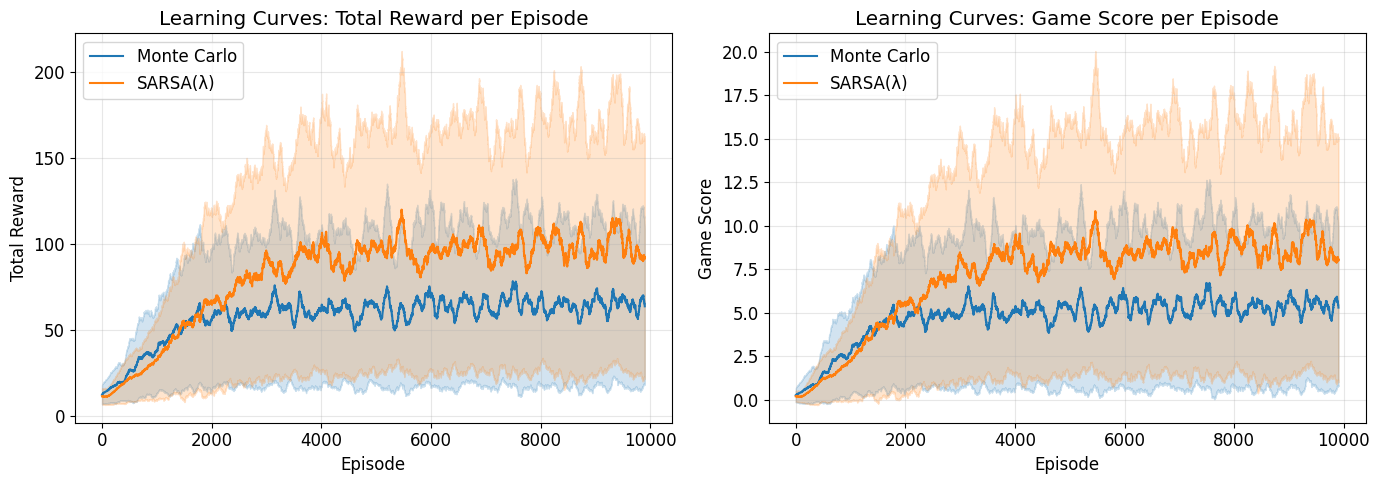

In [75]:
def smooth(data, window=100):
    """Apply moving average smoothing."""
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Monte Carlo': 'tab:blue', 'SARSA(λ)': 'tab:orange'}

# Rewards
ax1 = axes[0]
for algorithm in agents:
    mean_rewards = np.mean(all_rewards[algorithm], axis=0)
    std_rewards = np.std(all_rewards[algorithm], axis=0)
    smoothed = smooth(mean_rewards)
    ax1.plot(smoothed, label=algorithm, color=colors[algorithm])
    # Confidence band
    smoothed_std = smooth(std_rewards)
    x = np.arange(len(smoothed))
    ax1.fill_between(x, smoothed - smoothed_std, smoothed + smoothed_std, alpha=0.2, color=colors[algorithm])

ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.set_title('Learning Curves: Total Reward per Episode')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Scores
ax2 = axes[1]
for algorithm in agents:
    mean_scores = np.mean(all_scores[algorithm], axis=0)
    std_scores = np.std(all_scores[algorithm], axis=0)
    smoothed = smooth(mean_scores)
    ax2.plot(smoothed, label=algorithm, color=colors[algorithm])
    smoothed_std = smooth(std_scores)
    x = np.arange(len(smoothed))
    ax2.fill_between(x, smoothed - smoothed_std, smoothed + smoothed_std, alpha=0.2, color=colors[algorithm])

ax2.set_xlabel('Episode')
ax2.set_ylabel('Game Score')
ax2.set_title('Learning Curves: Game Score per Episode')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [76]:
# Final performance statistics
print("=" * 60)
print("Final Performance Summary (averaged over {} runs, last 500 episodes)".format(N_RUNS))
print("=" * 60)

for algorithm in agents:
    final_rewards = [np.mean(r[-500:]) for r in all_rewards[algorithm]]
    final_scores = [np.mean(s[-500:]) for s in all_scores[algorithm]]
    
    print(f"\n{algorithm}:")
    print(f"  Avg Reward: {np.mean(final_rewards):.2f} +/- {np.std(final_rewards):.2f}")
    print(f"  Avg Score:  {np.mean(final_scores):.2f} +/- {np.std(final_scores):.2f}")
    print(f"  Max Score:  {np.max([np.max(s) for s in all_scores[algorithm]])}")

Final Performance Summary (averaged over 5 runs, last 500 episodes)

Monte Carlo:
  Avg Reward: 65.24 +/- 4.64
  Avg Score:  5.41 +/- 0.45
  Max Score:  76

SARSA(λ):
  Avg Reward: 95.90 +/- 9.37
  Avg Score:  8.43 +/- 0.93
  Max Score:  96


---

## 6. State-Value Function Visualization

In [77]:
# Train single agents for visualization
agent_info_viz = agent_info_base.copy()
agent_info_viz["seed"] = 0

# Monte Carlo agent
rl_glue_mc = RLGlue(TextFlappyBirdEnvironment, MonteCarloAgent)
rl_glue_mc.rl_init(agent_info_viz, ENV_CONFIG)
for _ in tqdm(range(N_EPISODES), desc="Training MC for visualization"):
    rl_glue_mc.rl_episode(0)

# SARSA(λ) agent
rl_glue_sarsa = RLGlue(TextFlappyBirdEnvironment, SarsaLambdaAgent)
rl_glue_sarsa.rl_init(agent_info_viz, ENV_CONFIG)
for _ in tqdm(range(N_EPISODES), desc="Training SARSA(λ) for visualization"):
    rl_glue_sarsa.rl_episode(0)

# Get Q-tables (now dictionaries with tuple keys)
q_mc = rl_glue_mc.rl_agent_message("get_q")
q_sarsa = rl_glue_sarsa.rl_agent_message("get_q")

print(f"MC agent learned {len(q_mc)} states")
print(f"SARSA(λ) agent learned {len(q_sarsa)} states")

Training SARSA(λ) for visualization: 100%|██████████| 10000/10000 [30:23<00:00,  5.48it/s] 

MC agent learned 274 states
SARSA(λ) agent learned 273 states


In [78]:
def plot_value_function(q_dict, env_info, title, ax):
    """Plot state-value function V(s) = max_a Q(s,a) as heatmap.
    
    Args:
        q_dict: Dictionary mapping (x, y) tuples to Q-value arrays
    """
    # Get state bounds
    env = TextFlappyBirdEnvironment()
    env.env_init(env_info)
    x_min, x_max = env.x_min, env.x_max
    y_min, y_max = env.y_min, env.y_max
    env.env_cleanup()
    
    # Create value grid
    v_grid = np.full((y_max - y_min + 1, x_max - x_min + 1), np.nan)
    
    for (x, y), q_values in q_dict.items():
        if x_min <= x <= x_max and y_min <= y <= y_max:
            v_grid[y - y_min, x - x_min] = np.max(q_values)
    
    im = ax.imshow(v_grid, origin='lower', aspect='auto', cmap='viridis',
                   extent=[x_min-0.5, x_max+0.5, y_min-0.5, y_max+0.5])
    ax.set_xlabel('X Distance to Pipe')
    ax.set_ylabel('Y Distance to Gap Center')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='V(s)')

def plot_policy(q_dict, env_info, title, ax):
    """Plot policy (best action) as heatmap."""
    env = TextFlappyBirdEnvironment()
    env.env_init(env_info)
    x_min, x_max = env.x_min, env.x_max
    y_min, y_max = env.y_min, env.y_max
    env.env_cleanup()
    
    policy_grid = np.full((y_max - y_min + 1, x_max - x_min + 1), np.nan)
    
    for (x, y), q_values in q_dict.items():
        if x_min <= x <= x_max and y_min <= y <= y_max:
            policy_grid[y - y_min, x - x_min] = np.argmax(q_values)
    
    im = ax.imshow(policy_grid, origin='lower', aspect='auto', cmap='coolwarm',
                   extent=[x_min-0.5, x_max+0.5, y_min-0.5, y_max+0.5],
                   vmin=0, vmax=1)
    ax.set_xlabel('X Distance to Pipe')
    ax.set_ylabel('Y Distance to Gap Center')
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.ax.set_yticklabels(['Idle', 'Flap'])

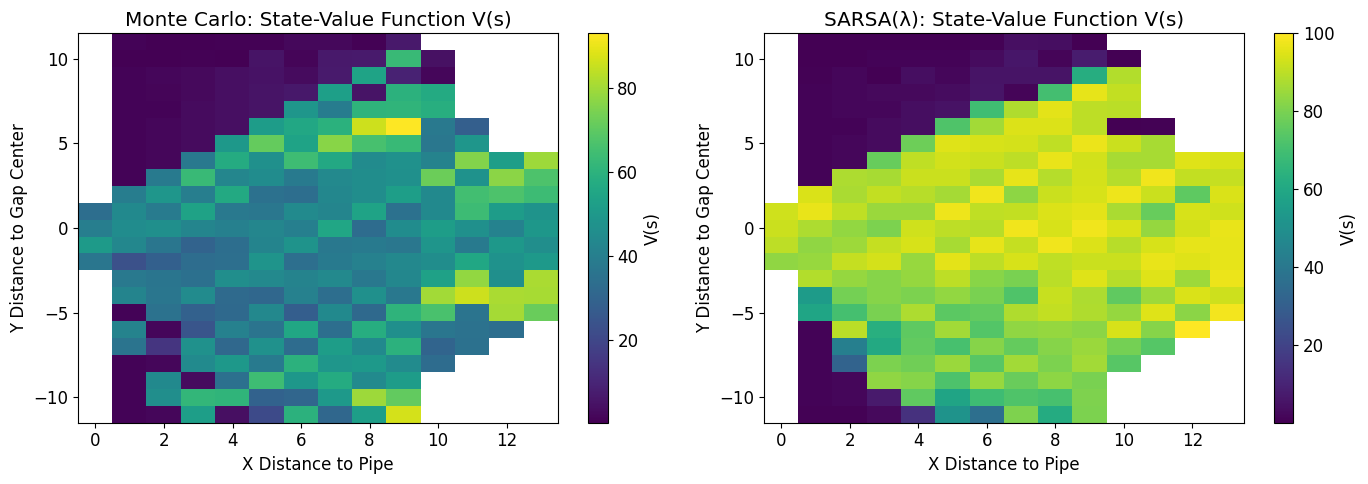

In [79]:
# Plot value functions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_value_function(q_mc, ENV_CONFIG, 'Monte Carlo: State-Value Function V(s)', axes[0])
plot_value_function(q_sarsa, ENV_CONFIG, 'SARSA(λ): State-Value Function V(s)', axes[1])
plt.tight_layout()
plt.savefig('value_functions.png', dpi=150, bbox_inches='tight')
plt.show()

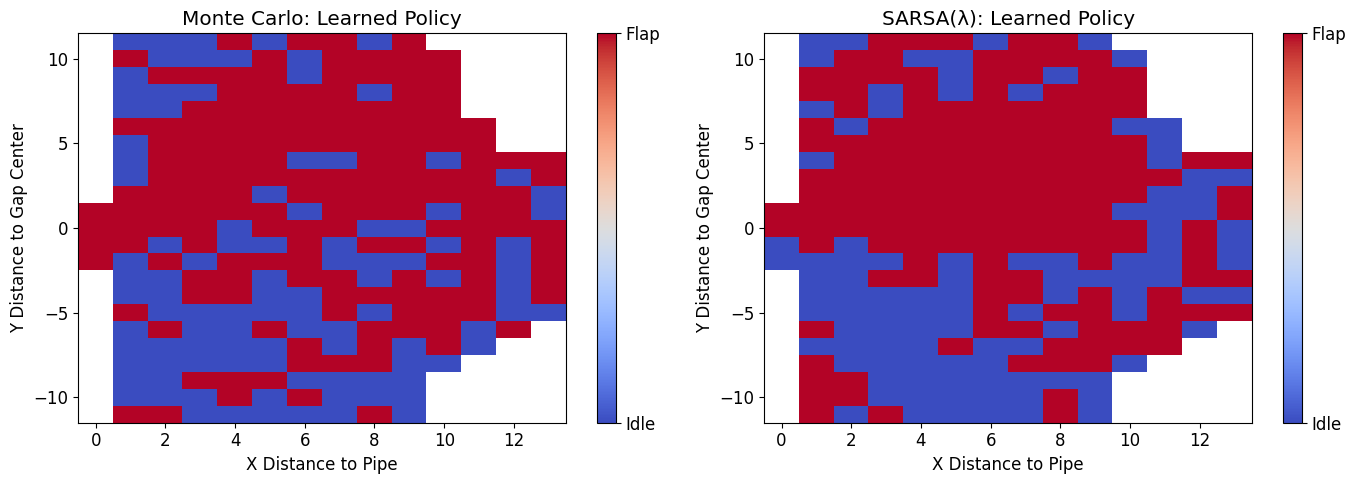

In [80]:
# Plot policies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_policy(q_mc, ENV_CONFIG, 'Monte Carlo: Learned Policy', axes[0])
plot_policy(q_sarsa, ENV_CONFIG, 'SARSA(λ): Learned Policy', axes[1])
plt.tight_layout()
plt.savefig('policies.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7. Parameter Sweeps

In [81]:
def run_parameter_sweep(agent_class, param_name, param_values, 
                        n_episodes=3000, n_runs=3):
    """Run parameter sweep for a given agent."""
    results = {}
    
    for value in tqdm(param_values, desc=f"Sweeping {param_name}"):
        run_scores = []
        
        for run in range(n_runs):
            agent_info = agent_info_base.copy()
            agent_info["seed"] = run
            agent_info[param_name] = value
            
            rl_glue = RLGlue(TextFlappyBirdEnvironment, agent_class)
            rl_glue.rl_init(agent_info, ENV_CONFIG)
            
            for _ in range(n_episodes):
                rl_glue.rl_episode(0)
            
            # Average reward over last 100 episodes
            final_rewards = []
            for _ in range(100):
                rl_glue.rl_episode(0)
                final_rewards.append(rl_glue.rl_return())
            run_scores.append(np.mean(final_rewards))
        
        results[value] = run_scores
    
    return results

In [82]:
# Learning rate (alpha) sweep
alpha_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

print("Alpha sweep for Monte Carlo...")
mc_alpha_results = run_parameter_sweep(MonteCarloAgent, 'step_size', alpha_values)

print("\nAlpha sweep for SARSA(λ)...")
sarsa_alpha_results = run_parameter_sweep(SarsaLambdaAgent, 'step_size', alpha_values)

Alpha sweep for Monte Carlo...


Sweeping step_size: 100%|██████████| 6/6 [06:58<00:00, 69.77s/it]



Alpha sweep for SARSA(λ)...


Sweeping step_size: 100%|██████████| 6/6 [55:06<00:00, 551.01s/it]


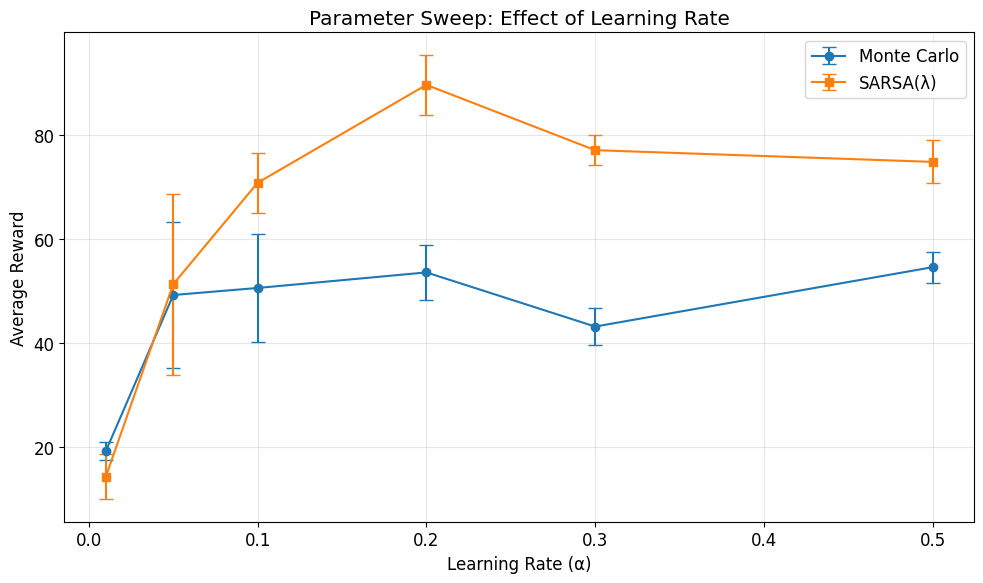

In [83]:
# Plot alpha sweep
fig, ax = plt.subplots(figsize=(10, 6))

mc_means = [np.mean(mc_alpha_results[a]) for a in alpha_values]
mc_stds = [np.std(mc_alpha_results[a]) for a in alpha_values]
sarsa_means = [np.mean(sarsa_alpha_results[a]) for a in alpha_values]
sarsa_stds = [np.std(sarsa_alpha_results[a]) for a in alpha_values]

ax.errorbar(alpha_values, mc_means, yerr=mc_stds, marker='o', 
            label='Monte Carlo', capsize=5, color='tab:blue')
ax.errorbar(alpha_values, sarsa_means, yerr=sarsa_stds, marker='s', 
            label='SARSA(λ)', capsize=5, color='tab:orange')

ax.set_xlabel('Learning Rate (α)')
ax.set_ylabel('Average Reward')
ax.set_title('Parameter Sweep: Effect of Learning Rate')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('alpha_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [84]:
# Lambda sweep for SARSA(λ)
lambda_values = [0.0, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]

print("Lambda sweep for SARSA(λ)...")
sarsa_lambda_results = run_parameter_sweep(SarsaLambdaAgent, 'lambda', lambda_values)

Lambda sweep for SARSA(λ)...


Sweeping lambda: 100%|██████████| 7/7 [31:26<00:00, 269.54s/it]


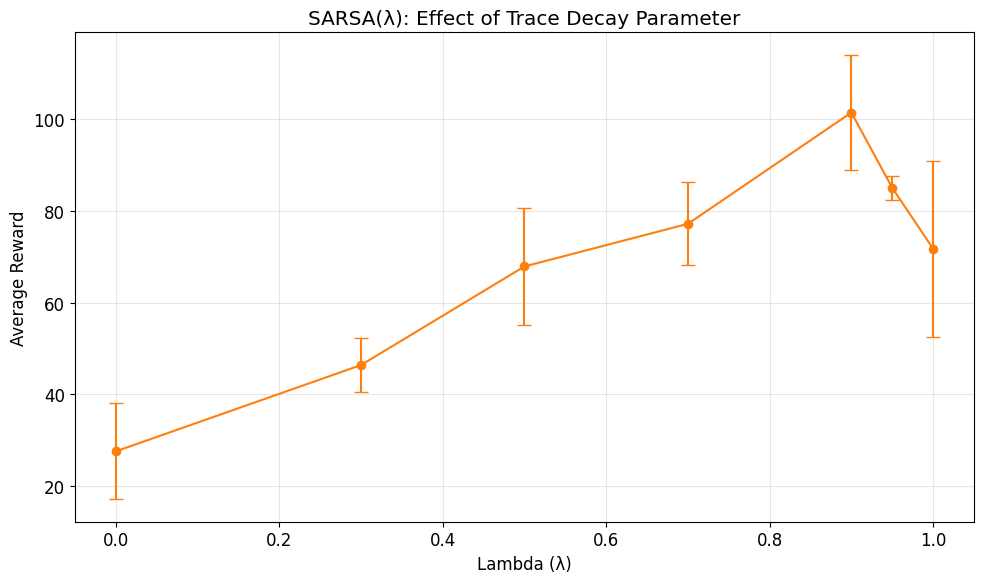

In [85]:
# Plot lambda sweep
fig, ax = plt.subplots(figsize=(10, 6))

lambda_means = [np.mean(sarsa_lambda_results[l]) for l in lambda_values]
lambda_stds = [np.std(sarsa_lambda_results[l]) for l in lambda_values]

ax.errorbar(lambda_values, lambda_means, yerr=lambda_stds, marker='o', 
            capsize=5, color='tab:orange')

ax.set_xlabel('Lambda (λ)')
ax.set_ylabel('Average Reward')
ax.set_title('SARSA(λ): Effect of Trace Decay Parameter')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lambda_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Generalization Test: Different Environment Configurations

In [86]:
def evaluate_agent(q_dict, test_config, n_episodes=100, max_steps=500):
    """Evaluate a trained Q-table on a given configuration.
    
    Args:
        q_dict: Trained Q-table (dictionary)
        test_config: Environment configuration dict
        n_episodes: Number of evaluation episodes
        max_steps: Maximum steps per episode (prevents infinite loops!)
    """
    
    class FixedPolicyAgent(BaseAgent):
        def agent_init(self, agent_info):
            self.q = agent_info['q_table']
        
        def agent_start(self, state):
            if state in self.q:
                return np.argmax(self.q[state])
            return 0  # Default to Idle for unseen states
        
        def agent_step(self, reward, state):
            if state in self.q:
                return np.argmax(self.q[state])
            return 0
        
        def agent_end(self, reward):
            pass
    
    rl_glue = RLGlue(TextFlappyBirdEnvironment, FixedPolicyAgent)
    rl_glue.rl_init({'q_table': q_dict}, test_config)
    
    rewards = []
    scores = []
    for _ in range(n_episodes):
        # IMPORTANT: Set max_steps to prevent infinite episodes!
        rl_glue.rl_episode(max_steps)
        rewards.append(rl_glue.rl_return())
        scores.append(rl_glue.rl_env_message("get_score"))
    
    return np.mean(rewards), np.std(rewards), np.mean(scores), np.std(scores)

In [87]:

# This tests generalization to unseen environment parameters
test_configs = [
    {'height' : 15 , 'width' : 20 , 'pipe_gap':4 , 'name': 'Training config'},
    {'height': 15, 'width': 20, 'pipe_gap': 3, 'name': 'Smaller Gap (harder)'},
    {'height': 12, 'width': 18, 'pipe_gap': 5, 'name': 'Smaller Screen, Larger Gap'},
]

print("Evaluating trained agents on NEW configurations (different from training)...")
print("Training config was: height=15, width=20, pipe_gap=4")
print("=" * 70)

results_table = []

for config in test_configs:
    name = config.pop('name')
    
    print(f"\nEvaluating on: {name} (height={config['height']}, width={config['width']}, gap={config['pipe_gap']})")
    
    mc_res = evaluate_agent(q_mc, config, n_episodes=50, max_steps=500)
    sarsa_res = evaluate_agent(q_sarsa, config, n_episodes=50, max_steps=500)
    
    config['name'] = name
    results_table.append({
        'config': name,
        'mc_reward': mc_res[0],
        'mc_score': mc_res[2],
        'sarsa_reward': sarsa_res[0],
        'sarsa_score': sarsa_res[2]
    })
    
    print(f"  MC:       Reward = {mc_res[0]:.1f} +/- {mc_res[1]:.1f}, Score = {mc_res[2]:.1f}")
    print(f"  SARSA(λ): Reward = {sarsa_res[0]:.1f} +/- {sarsa_res[1]:.1f}, Score = {sarsa_res[2]:.1f}")

Evaluating trained agents on NEW configurations (different from training)...
Training config was: height=15, width=20, pipe_gap=4

Evaluating on: Training config (height=15, width=20, gap=4)
  MC:       Reward = 318.1 +/- 146.6, Score = 30.8
  SARSA(λ): Reward = 499.0 +/- 0.0, Score = 49.0

Evaluating on: Smaller Gap (harder) (height=15, width=20, gap=3)
  MC:       Reward = 29.5 +/- 22.3, Score = 1.8
  SARSA(λ): Reward = 77.7 +/- 80.9, Score = 6.5

Evaluating on: Smaller Screen, Larger Gap (height=12, width=18, gap=5)
  MC:       Reward = 52.1 +/- 42.5, Score = 5.0
  SARSA(λ): Reward = 499.0 +/- 0.0, Score = 55.0


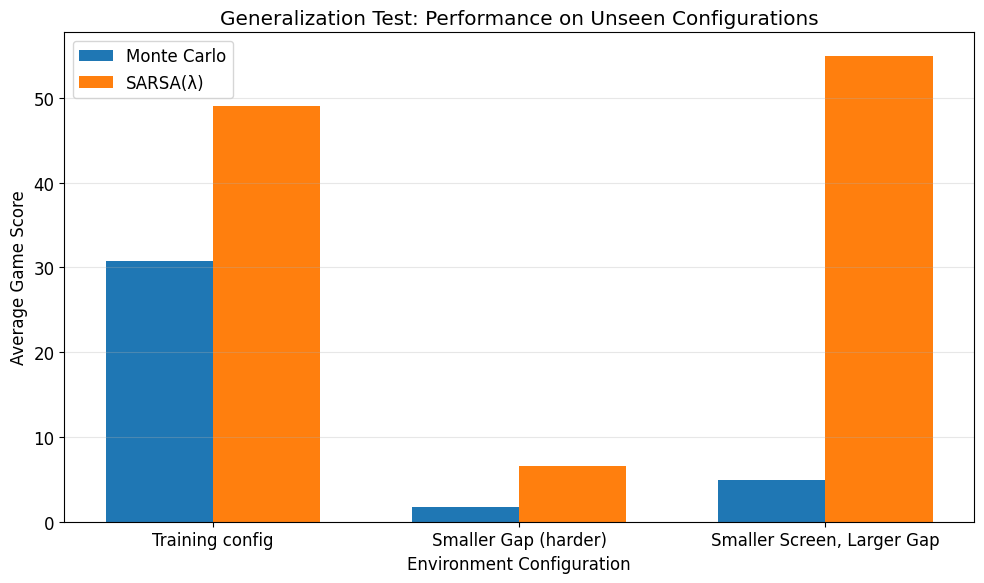


Interpretation:
- Lower scores on new configurations indicate the policy is specialized to training config
- This is expected since the state space (x_dist, y_dist) changes with different parameters


In [88]:
# Plot generalization results
fig, ax = plt.subplots(figsize=(10, 6))

config_names = [r['config'] for r in results_table]
x = np.arange(len(config_names))
width = 0.35

mc_scores = [r['mc_score'] for r in results_table]
sarsa_scores = [r['sarsa_score'] for r in results_table]

ax.bar(x - width/2, mc_scores, width, label='Monte Carlo', color='tab:blue')
ax.bar(x + width/2, sarsa_scores, width, label='SARSA(λ)', color='tab:orange')

ax.set_xlabel('Environment Configuration')
ax.set_ylabel('Average Game Score')
ax.set_title('Generalization Test: Performance on Unseen Configurations')
ax.set_xticks(x)
ax.set_xticklabels(config_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('generalization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- Lower scores on new configurations indicate the policy is specialized to training config")
print("- This is expected since the state space (x_dist, y_dist) changes with different parameters")

---

## 9. Save Trained Agents

In [89]:
# Save Q-tables
with open('mc_agent_Q.pkl', 'wb') as f:
    pickle.dump(q_mc, f)

with open('sarsa_agent_Q.pkl', 'wb') as f:
    pickle.dump(q_sarsa, f)

print("Trained Q-tables saved successfully!")
print(f"MC agent: {len(q_mc)} states")
print(f"SARSA(λ) agent: {len(q_sarsa)} states")

Trained Q-tables saved successfully!
MC agent: 274 states
SARSA(λ) agent: 273 states


---

## Summary

This notebook implemented and compared two RL agents for Text Flappy Bird using the RL-Glue framework:

### Monte Carlo Control (Every-Visit)
- **Type:** Model-free, on-policy
- **Update:** End of episode using complete returns (updates for every (s,a) visit)
- **Q-table:** Dictionary with (x_dist, y_dist) tuple keys
- **Strengths:** Simple, unbiased estimates, more updates per episode than first-visit
- **Weaknesses:** High variance, requires complete episodes

### SARSA(λ)
- **Type:** Model-free, on-policy with eligibility traces
- **Update:** Every step with trace-based credit assignment
- **Q-table:** Dictionary with (x_dist, y_dist) tuple keys
- **Strengths:** Online learning, faster convergence, flexible credit assignment via λ
- **Weaknesses:** More hyperparameters, sensitive to step-size

### Experimental Protocol
- **5 independent runs** with different random seeds to assess statistical reliability
- **Average reward** = total steps survived (agent gets +1 per step alive)
- **Average score** = number of pipes passed (game score)
- Results averaged across runs with standard deviation for confidence intervals

### Key Findings
1. SARSA(λ) typically learns faster due to online updates
2. Both agents learn effective policies for navigating through pipes
3. The λ parameter allows tuning between TD(0) and Monte Carlo behavior
4. Performance degrades on significantly different environment configurations